code to generate a zadoff-chu sequence and figure our it usage

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def zadoff_chu(N, u):
    q = 0
    N_0 = np.arange(0, N, 1)
    N_1 = np.arange(1, N + 1, 1)
    
    if N % 2 == 1:  # Odd length
        y = np.exp(-1j * u * np.pi / N * np.multiply(N_0, (N_1 + 2 * q)))
    else:  # Even length
        y = np.exp(-1j * u * np.pi / N * (N_0**2))
        
    return y   

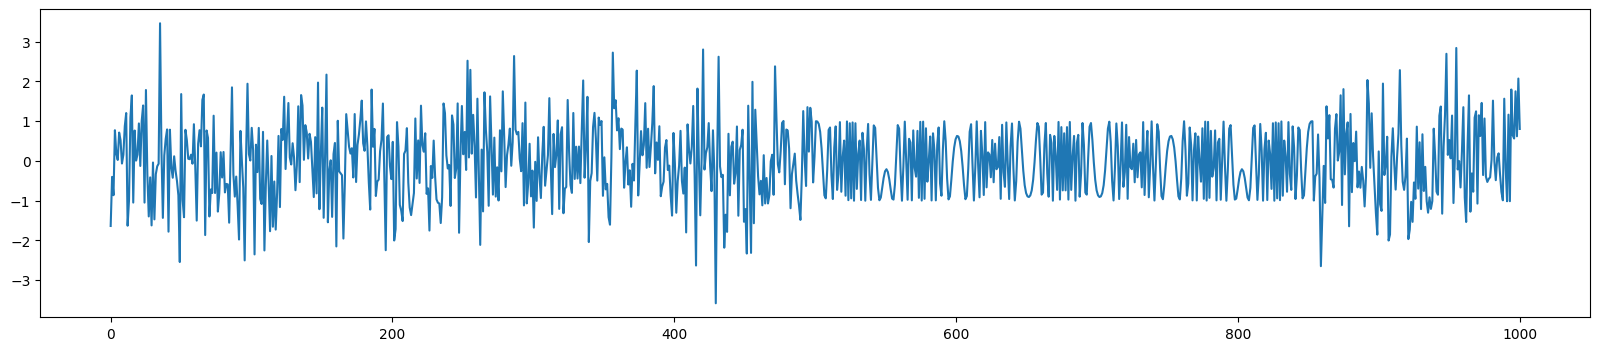

In [ ]:
Tmax=1000
len_zadoff_chu=353
u_zadoff_chu=7

t=np.linspace(0,Tmax,Tmax)
zadoff_chu_seq=zadoff_chu(len_zadoff_chu,u_zadoff_chu)

pad_len = Tmax - len(zadoff_chu_seq)

noise = np.random.randn(pad_len)   # Gaussian noise (mean=0, std=1)

x_t = np.concatenate([zadoff_chu_seq, noise])

shift=500
x_t=np.roll(x_t,shift)

plt.figure(figsize=(20,4))
plt.plot(t,np.real(x_t))


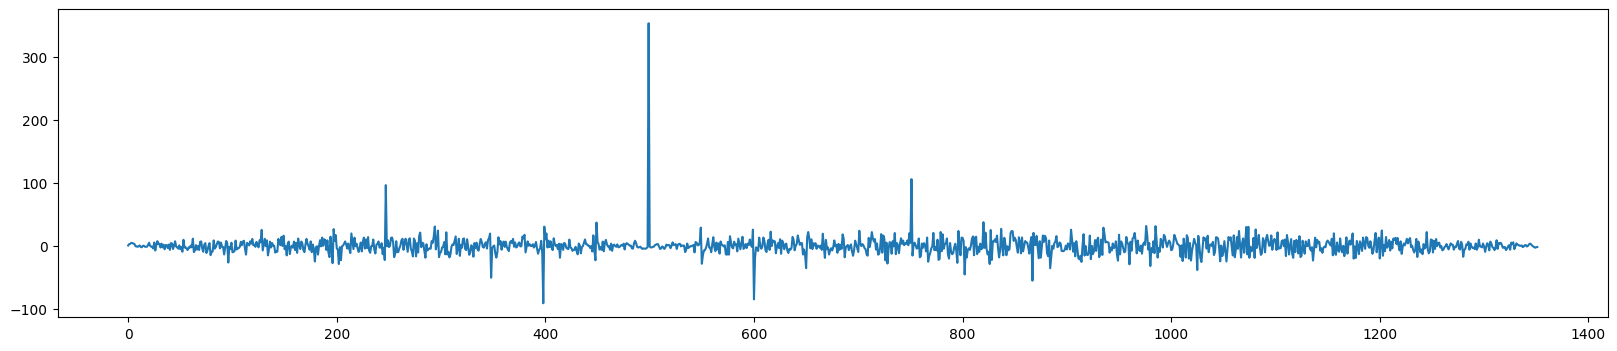

In [ ]:
corr = np.correlate(zadoff_chu_seq, x_t, mode='full')

plt.figure(figsize=(20,4))
plt.plot(t,np.real(corr))

use valid mode when detecting the sequence

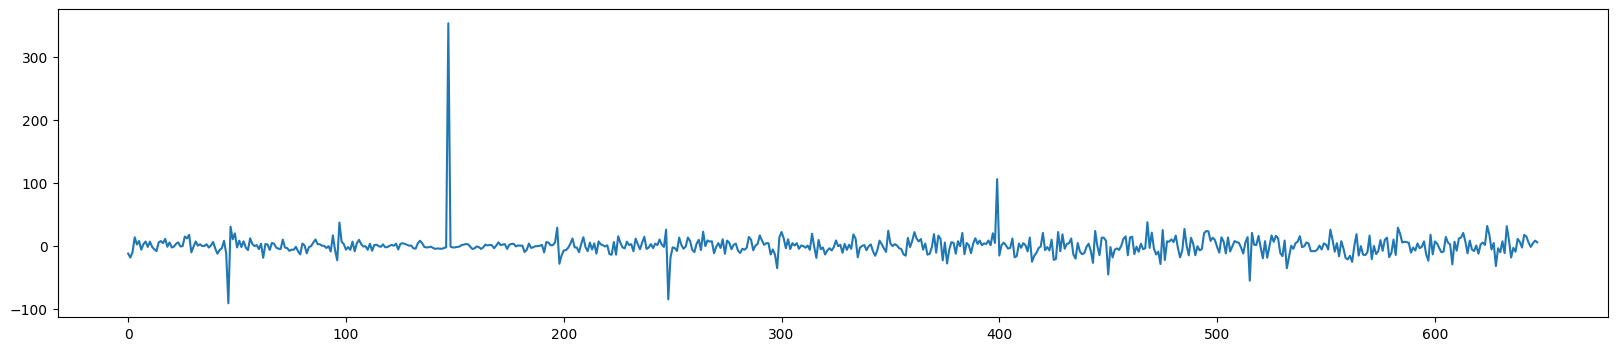

In [41]:
corr=np.correlate(zadoff_chu_seq, x_t, mode='valid')

plt.figure(figsize=(20,4))
plt.plot(np.real(corr))

In [39]:
index = np.argmax(corr)

print("Match at index:", len(corr)-index)

Match at index: 501
